<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                5000 non-null   object 
 1   customer_id             5000 non-null   object 
 2   product_id              5000 non-null   object 
 3   product_category        5000 non-null   object 
 4   price                   5000 non-null   float64
 5   quantity                5000 non-null   int64  
 6   order_datetime          5000 non-null   object 
 7   order_weekday           5000 non-null   object 
 8   order_hour              5000 non-null   int64  
 9   delivery_days           5000 non-null   int64  
 10  shipping_type           5000 non-null   object 
 11  is_prime_member         5000 non-null   int64  
 12  seller_rating           5000 non-null   float64
 13  previous_returns_count  5000 non-null   int64  
 14  customer_tenure_days    5000 non-null   

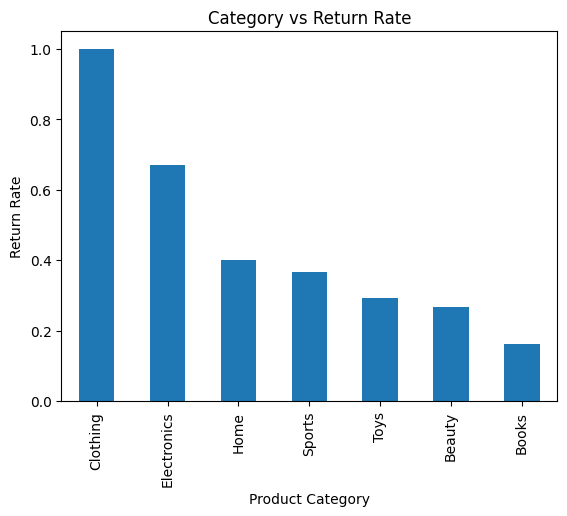

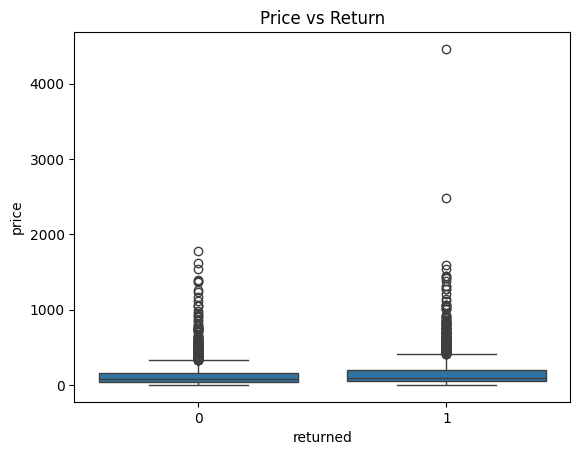

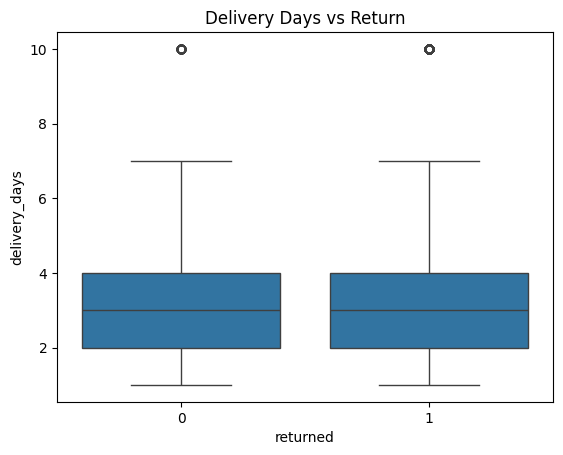

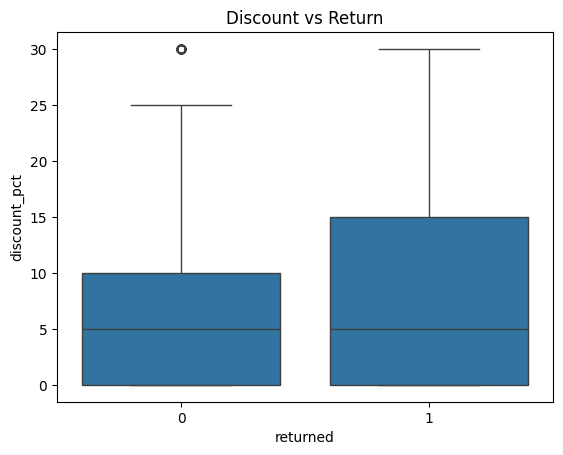

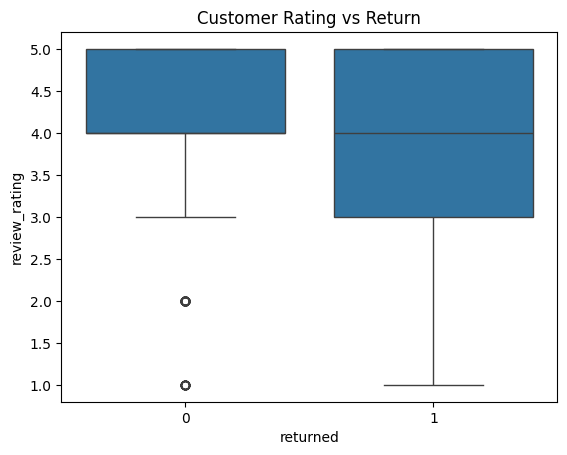

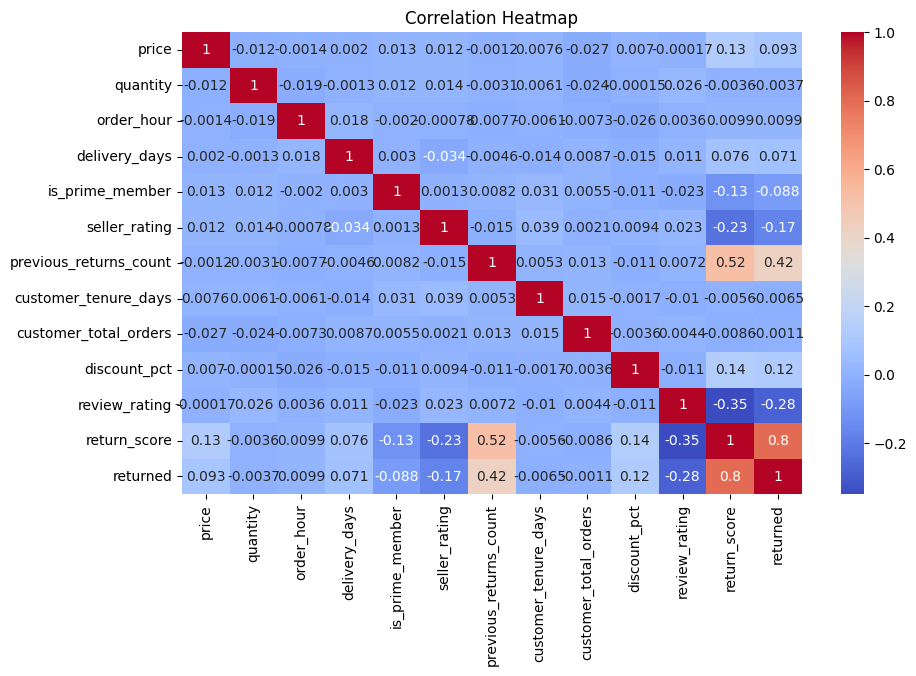

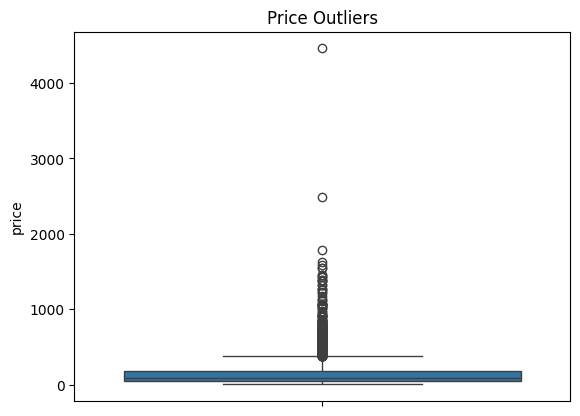

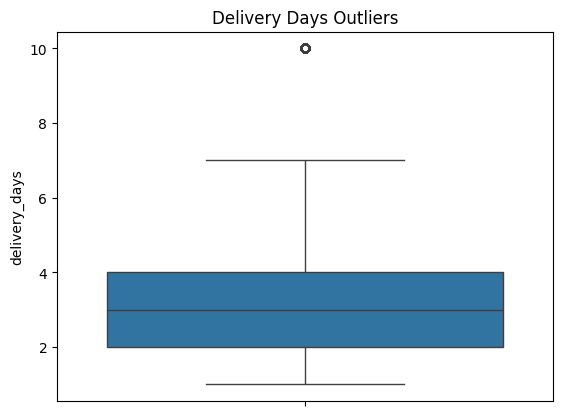

Outliers Count: 372
P-value: 4.581014616563138e-07
Delivery delay significantly affects returns


,count
customer_segment,
Premium Customer,2500
Normal,1379
High Return Customer,1121


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('amazon_returns_dataset_cleaned.csv')
# First 5 Rows
df.head()
# Dataset Size
df.shape
# Column Names
df.columns
# Dataset Information
df.info()
# Missing Values
df.isnull().sum()
# Duplicate Records Count
df.duplicated().sum()
# Remove Duplicates
df = df.drop_duplicates()
# Total Orders
print("Total Orders:",len(df))
# Statistical Summary
df.describe()
# Numerical Columns
df.select_dtypes(include=['number']).columns
df.mean(numeric_only=True)
df['returned'].value_counts()
print("Total Returned Products:",df['returned'].sum())
print("Return Percentage:",(df['returned'].sum() / len(df)) * 100)
df.median(numeric_only=True)
df.std(numeric_only=True)
df.quantile([0.25, 0.50, 0.75], numeric_only=True)
print("Average Delivery Duration:",df['delivery_days'].mean())
print("Average Product Price:",df['price'].mean())
print("Average Customer Rating:",df['review_rating'].mean())
df.groupby('product_category')['returned'].mean().sort_values(ascending=False)
category_returns = df.groupby('product_category')['returned'].mean().sort_values(ascending=False)
category_returns.plot(kind='bar')
plt.title('Category vs Return Rate')
plt.xlabel('Product Category')
plt.ylabel('Return Rate')
plt.show()
sns.boxplot(x='returned', y='price', data=df)
plt.title('Price vs Return')
plt.show()
sns.boxplot(x='returned', y='delivery_days', data=df)
plt.title('Delivery Days vs Return')
plt.show()
sns.boxplot(x='returned', y='discount_pct', data=df)
plt.title('Discount vs Return')
plt.show()
sns.boxplot(x='returned', y='review_rating', data=df)
plt.title('Customer Rating vs Return')
plt.show()
plt.figure(figsize=(10,6))
sns.heatmap(
    df.select_dtypes(include=['number']).corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()
sns.boxplot(y=df['price'])
plt.title('Price Outliers')
plt.show()
sns.boxplot(y=df['delivery_days'])
plt.title('Delivery Days Outliers')
plt.show()
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print("Outliers Count:",len(outliers))
df.groupby('customer_id')['returned'].sum().sort_values(ascending=False).head(10)
from scipy.stats import ttest_ind
returned_orders = df[df['returned'] == 1]['delivery_days']
non_returned_orders = df[df['returned'] == 0]['delivery_days']
t_stat, p_value = ttest_ind(returned_orders, non_returned_orders)
print("P-value:", p_value)
if p_value < 0.05:
    print("Delivery delay significantly affects returns")
else:
    print("Delivery delay does not significantly affect returns")
df['customer_segment'] = 'Normal'
df.loc[df['returned'] == 1, 'customer_segment'] = 'High Return Customer'
df['customer_segment'].value_counts()
df.loc[df['price'] > df['price'].median(), 'customer_segment'] = 'Premium Customer'
df['customer_segment'].value_counts()



In [2]:
import zipfile

with zipfile.ZipFile('archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall()

In [5]:
import pandas as pd

# Excel file read
df = pd.read_excel('amazon_returns_dataset_cleaned.xlsx')

# CSV file save
df.to_csv('amazon_returns_dataset_cleaned.csv', index=False)

print("CSV file created successfully!")

CSV file created successfully!
